In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import geotherm_calculator as gc
import planetary_grid_reader as pgr
import habitability_calculator as hc

from astropy import constants as const
from matplotlib.patches import Patch

# Librería IAPWS para propiedades del agua
from iapws import IAPWS95
from iapws.iapws97 import IAPWS97
from iapws.iapws08 import _Tf, _Tb, _Triple
from iapws._iapws import _Sublimation_Pressure, _Melting_Pressure

In [2]:
Gpa = 1e9
Mpa = 1e6
km = 1e3
to = 1.386e9 #Terrestrial Oceans volume in km3

Me = const.M_earth.value # Earth mass (kg) 
Re = const.R_earth.value # Earth radius (m) 

In [3]:
mineral_objects = gc.get_mineral_objects()
rocks = gc.prepare_rocks_dict(mineral_objects=mineral_objects)
upper = rocks['upper']

In [4]:
planetary_grid_path = "PlanetaryGrid"
target_folder = "CMF_0.30-IMF_0.00"
planet = 'M1.00'
folder_path = os.path.join(planetary_grid_path, target_folder)

if not os.path.isdir(folder_path):
    print(f"Error: Folder '{folder_path}' not found.")
else:
    files = sorted(os.listdir(folder_path))
    tevol_files = [f for f in files if f.startswith(planet) and f.endswith('TEVOL.dat')]
    if not tevol_files:
        print(f"No TEVOL.dat files found in {folder_path}")
    else:
        for tfile in tevol_files:
            path_tevol = os.path.join(folder_path, tfile)
            data_tevol = pgr.read_tevol_dat(path_tevol)
            ts = np.array(data_tevol['#t']) /1e9
            qm = np.array(data_tevol['Qm']) 
            qss = qm / (4*np.pi*Re**2) 
    



In [5]:
Tsurf = hc.T_eq(1)
boundaries = gc.scale_layer_boundaries(Re)
As_mant = np.zeros_like(ts)
As_surf = np.zeros_like(ts)

As_surf = np.zeros_like(ts)
As_mant = np.zeros_like(ts)

for i, t in enumerate(ts):
    As_surf[i] = gc.A_surface_temporal(t)
    As_mant[i] = gc.A_mantle_temporal(t)

Text(4.55, 2.2407547979540766e-05, 'Present')

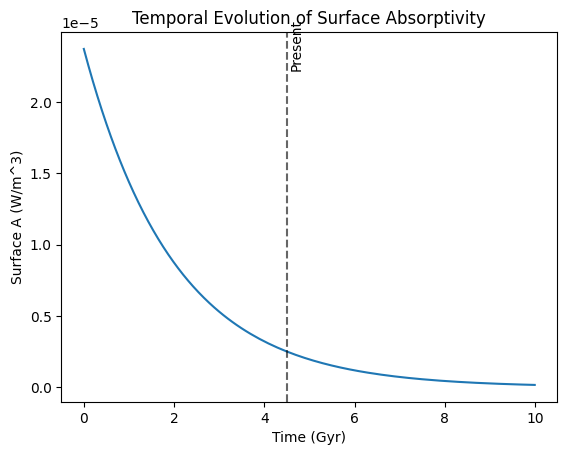

In [16]:
plt.plot(ts, As_surf)
plt.xlabel('Time (Gyr)')
plt.ylabel('Surface A (W/m^3)')
plt.title('Temporal Evolution of Surface Absorptivity')
plt.axvline(4.5, color='k', linestyle='--', alpha=0.6)
plt.text(4.55, 0.9*plt.ylim()[1], "Present", rotation=90)


In [31]:
def habitability_vs_time_geological(rocks,
                                R_planet,
                                M_planet, Tsurf,
                                qss,
                                ts,  
                                composition=None,
                                information=True):
    
    boundaries = gc.scale_layer_boundaries(R_planet=R_planet)
    t_geological =ts


    df_geothermic_evolution = gc.calculate_geotherm_evolution(
        rocks=rocks,
        R_planet=R_planet,
        M_total=M_planet,
        z_max=20e3,
        composition=composition,
        boundaries=boundaries,
        dz=100.0,
        qss=qss,
        T_top=Tsurf,
        t_Ga=t_geological)
    

    t_Ga = df_geothermic_evolution['t_Ga']
    q_s = df_geothermic_evolution['q_s']
    profiles = df_geothermic_evolution['profiles']

    # Listas para almacenar resultados
    water_thickness_time = []
    habitable_thickness_time = []
    water_depth_top_time = []
    water_depth_bottom_time = []
    habitable_depth_top_time = []
    habitable_depth_bottom_time = []

    print("=" * 80)
    print("CALCULANDO CapaS DE HABITABILIDAD EN EL TIEMPO GEOLÓGICO")
    print("=" * 80)

    # Procesar cada perfil geotérmico en el tiempo
    for i, (t, q, df_profile) in enumerate(zip(t_Ga, q_s, profiles)):
        print(f"\nTiempo: {t:.2f} Ga | Flujo de calor: {q*1000:.1f} mW/m²")
        
        # Calcular Capas de habitabilidad
        liquid_data = hc.find_liquid_zone(df_profile, information=False)
        habitable_data = hc.find_habitable_zone(liquid_data['indices'], df_profile, information=False)
        
        # Almacenar datos de Capa de aguabilidad
        if liquid_data['liquid_zone'] is not None:
            water_top = liquid_data['liquid_zone'][0] / 1000  # km
            water_bottom = liquid_data['liquid_zone'][-1] / 1000  # km
            water_thick = water_bottom - water_top
            
            water_depth_top_time.append(water_top)
            water_depth_bottom_time.append(water_bottom)
            water_thickness_time.append(water_thick)
            if information:
                print(f"  💧 Capa de Aguabilidad: {water_top:.2f} - {water_bottom:.2f} km (espesor: {water_thick:.2f} km)")
        else:
            water_depth_top_time.append(np.nan)
            water_depth_bottom_time.append(np.nan)
            water_thickness_time.append(0)
            if information:
                print(f"  💧 Capa de Aguabilidad: No existe")
        
        # Almacenar datos de Capa habitable
        if habitable_data['habitable_zone'] is not None:
            hab_top = habitable_data['habitable_zone'][0] / 1000  # km
            hab_bottom = habitable_data['habitable_zone'][-1] / 1000  # km
            hab_thick = hab_bottom - hab_top
            
            habitable_depth_top_time.append(hab_top)
            habitable_depth_bottom_time.append(hab_bottom)
            habitable_thickness_time.append(hab_thick)

            if information:
                print(f"  🦠 Capa Habitable: {hab_top:.2f} - {hab_bottom:.2f} km (espesor: {hab_thick:.2f} km)")
        else:
            habitable_depth_top_time.append(np.nan)
            habitable_depth_bottom_time.append(np.nan)
            habitable_thickness_time.append(0)
            if information:
                print(f"  🦠 Capa Habitable: No existe")

    # Convertir a arrays numpy
    water_thickness_time = np.array(water_thickness_time)
    habitable_thickness_time = np.array(habitable_thickness_time)
    water_depth_top_time = np.array(water_depth_top_time)
    water_depth_bottom_time = np.array(water_depth_bottom_time)
    habitable_depth_top_time = np.array(habitable_depth_top_time)
    habitable_depth_bottom_time = np.array(habitable_depth_bottom_time)
    
    data_time = {
                't_Ga': t_Ga,
                'q_s': q_s,
                'water_thickness_time': water_thickness_time,
                'habitable_thickness_time': habitable_thickness_time,
                'water_depth_top_time': water_depth_top_time,
                'water_depth_bottom_time': water_depth_bottom_time,
                'habitable_depth_top_time': habitable_depth_top_time,
                'habitable_depth_bottom_time': habitable_depth_bottom_time,
                'attributes': {
                    'R_planet': R_planet,
                    'M_planet': M_planet,
                    'composition': composition,
                }
        }
    
    return data_time

def plots_habitability_vs_time_geological(data_time):
    t_Ga = data_time['t_Ga']
    water_thickness_time = data_time['water_thickness_time']
    habitable_thickness_time = data_time['habitable_thickness_time']
    water_depth_top_time = data_time['water_depth_top_time']
    water_depth_bottom_time = data_time['water_depth_bottom_time']
    habitable_depth_top_time = data_time['habitable_depth_top_time']
    habitable_depth_bottom_time = data_time['habitable_depth_bottom_time']
    attributes = data_time['attributes']
    R_planet = attributes['R_planet']
    M_planet = attributes['M_planet']
    composition = attributes['composition']

    # =============================================================================
    # VISUALIZACIÓN: EVOLUCIÓN TEMPORAL DE CapaS DE HABITABILIDAD
    # =============================================================================

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    # PANEL 1: ESPESOR DE CapaS vs TIEMPO
    ax1 = axes[0, 0]
    ax1.plot(t_Ga, water_thickness_time, 'b-', linewidth=3, marker='o', 
            markersize=8, label='Capa de Aguabilidad', zorder=3)
    ax1.plot(t_Ga, habitable_thickness_time, 'g-', linewidth=3, marker='s', 
            markersize=8, label='Capa Habitable', zorder=3)
    ax1.fill_between(t_Ga, 0, water_thickness_time, color='lightskyblue', alpha=0.3, zorder=1)
    ax1.fill_between(t_Ga, 0, habitable_thickness_time, color='lightgreen', alpha=0.4, zorder=2)

    ax1.set_xlabel('Tiempo (Ga)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Espesor de la Capa (km)', fontsize=13, fontweight='bold')
    ax1.set_title('Evolución del Espesor de Capas Habitables\nen el Tiempo Geológico', 
                fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=11, framealpha=0.95)
    ax1.grid(True, alpha=0.3, linestyle=':', linewidth=0.7)
    ax1.set_xlim(0, max(t_Ga))
    ax1.set_ylim(0, max(water_thickness_time) * 1.1)

    # PANEL 2: PROFUNDIDAD DE LÍMITES DE Capa DE AGUABILIDAD vs TIEMPO
    ax2 = axes[0, 1]
    # Filtrar NaN para graficar
    valid_water = ~np.isnan(water_depth_top_time)
    if valid_water.any():
        ax2.plot(t_Ga[valid_water], water_depth_top_time[valid_water], 'b--', 
                linewidth=2.5, marker='o', markersize=7, label='Tope Capa de Aguabilidad', zorder=3)
        ax2.plot(t_Ga[valid_water], water_depth_bottom_time[valid_water], 'b-', 
                linewidth=2.5, marker='o', markersize=7, label='Base Capa de Aguabilidad', zorder=3)
        ax2.fill_between(t_Ga[valid_water], water_depth_top_time[valid_water], 
                        water_depth_bottom_time[valid_water], 
                        color='lightskyblue', alpha=0.4, zorder=1)

    ax2.set_xlabel('Tiempo (Ga)', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Profundidad (km)', fontsize=13, fontweight='bold')
    ax2.set_title('Evolución de Límites de Capa de Aguabilidad\ncon el Tiempo', 
                fontsize=14, fontweight='bold')
    ax2.legend(loc='upper left', fontsize=10, framealpha=0.95)
    ax2.grid(True, alpha=0.3, linestyle=':', linewidth=0.7)
    ax2.invert_yaxis()  # Profundidad crece hacia abajo
    ax2.set_xlim(0, max(t_Ga))

    # PANEL 3: PROFUNDIDAD DE LÍMITES DE Capa HABITABLE vs TIEMPO
    ax3 = axes[1, 0]
    # Filtrar NaN para graficar
    valid_hab = ~np.isnan(habitable_depth_top_time)
    if valid_hab.any():
        ax3.plot(t_Ga[valid_hab], habitable_depth_top_time[valid_hab], 'g--', 
                linewidth=2.5, marker='s', markersize=7, label='Tope Capa Habitable', zorder=3)
        ax3.plot(t_Ga[valid_hab], habitable_depth_bottom_time[valid_hab], 'g-', 
                linewidth=2.5, marker='s', markersize=7, label='Base Capa Habitable', zorder=3)
        ax3.fill_between(t_Ga[valid_hab], habitable_depth_top_time[valid_hab], 
                        habitable_depth_bottom_time[valid_hab], 
                        color='lightgreen', alpha=0.5, zorder=1)

    ax3.set_xlabel('Tiempo (Ga)', fontsize=13, fontweight='bold')
    ax3.set_ylabel('Profundidad (km)', fontsize=13, fontweight='bold')
    ax3.set_title('Evolución de Límites de Capa Habitable\ncon el Tiempo', 
                fontsize=14, fontweight='bold')
    ax3.legend(loc='upper left', fontsize=10, framealpha=0.95)
    ax3.grid(True, alpha=0.3, linestyle=':', linewidth=0.7)
    ax3.invert_yaxis()  # Profundidad crece hacia abajo
    ax3.set_xlim(0, max(t_Ga))

    # PANEL 4: FRACCIÓN HABITABLE vs TIEMPO
    ax4 = axes[1, 1]
    # Calcular fracción habitable (evitar división por cero)
    frac_habitable = np.where(water_thickness_time > 0, 
                            (habitable_thickness_time / water_thickness_time) * 100, 
                            0)
    ax4.plot(t_Ga, frac_habitable, 'purple', linewidth=3, marker='D', 
            markersize=8, label='Fracción Habitable', zorder=3)
    ax4.fill_between(t_Ga, 0, frac_habitable, color='plum', alpha=0.4, zorder=1)
    ax4.axhline(50, color='red', linestyle='--', linewidth=2, alpha=0.5, 
                label='50% de referencia', zorder=2)

    ax4.set_xlabel('Tiempo (Ga)', fontsize=13, fontweight='bold')
    ax4.set_ylabel('Fracción Habitable (%)', fontsize=13, fontweight='bold')
    ax4.set_title('Fracción de Capa de Aguabilidad que es Habitable\nvs Tiempo', 
                fontsize=14, fontweight='bold')
    ax4.legend(loc='best', fontsize=11, framealpha=0.95)
    ax4.grid(True, alpha=0.3, linestyle=':', linewidth=0.7)
    ax4.set_xlim(0, max(t_Ga))
    ax4.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

    # =============================================================================
    # RESUMEN ESTADÍSTICO
    # =============================================================================

    print("\n" + "=" * 80)
    print("RESUMEN ESTADÍSTICO: EVOLUCIÓN TEMPORAL DE HABITABILIDAD")
    print("=" * 80)

    print(f"\n📊 Capa DE AGUABILIDAD:")
    print(f"   Espesor inicial (0 Ga): {water_thickness_time[0]:.2f} km")
    print(f"   Espesor final ({t_Ga[-1]:.2f} Ga): {water_thickness_time[-1]:.2f} km")
    print(f"   Cambio total: {water_thickness_time[-1] - water_thickness_time[0]:+.2f} km")
    print(f"   Máximo espesor: {water_thickness_time.max():.2f} km (a {t_Ga[np.argmax(water_thickness_time)]:.2f} Ga)")

    print(f"\n🦠 Capa HABITABLE:")
    print(f"   Espesor inicial (0 Ga): {habitable_thickness_time[0]:.2f} km")
    print(f"   Espesor final ({t_Ga[-1]:.2f} Ga): {habitable_thickness_time[-1]:.2f} km")
    print(f"   Cambio total: {habitable_thickness_time[-1] - habitable_thickness_time[0]:+.2f} km")
    print(f"   Máximo espesor: {habitable_thickness_time.max():.2f} km (a {t_Ga[np.argmax(habitable_thickness_time)]:.2f} Ga)")

    print(f"\n📉 FRACCIÓN HABITABLE:")
    print(f"   Inicial (0 Ga): {frac_habitable[0]:.1f}%")
    print(f"   Final ({t_Ga[-1]:.2f} Ga): {frac_habitable[-1]:.1f}%")
    print(f"   Cambio total: {frac_habitable[-1] - frac_habitable[0]:+.1f}%")

    print("\n" + "=" * 80)

In [23]:
data_time = habitability_vs_time_geological(rocks=rocks,
                                            R_planet=Re,
                                            M_planet=Me,
                                            Tsurf=Tsurf,
                                            qss = qss,
                                            ts=ts,
                                            information=False)

CALCULANDO EVOLUCIÓN TEMPORAL DEL GRADIENTE GEOTÉRMICO
Modelo: Turcotte & Schubert (2014)
Número de tiempos: 352
R_planet = 6.378 x 10^6 m
M_total = 5.972 x 10^24 kg
⚠️  T calculada (2218.7 K) excede límite seguro en z = 1.50 km
   Deteniendo cálculo en capa 15.

📊 Perfil parcial retornado:
   Profundidad calculada: 0 - 1.50 km (de 20.0 km solicitados)
   Temperatura máxima alcanzada: 2095.3 K
   Capas calculadas: 16 / 201
   Porcentaje completado: 8.0%

  t =  0.000 Ga | q_s = 3081.8 mW/m² | dT/dz = 1207.5 K/km
⚠️  T calculada (2153.6 K) excede límite seguro en z = 1.70 km
   Deteniendo cálculo en capa 17.

📊 Perfil parcial retornado:
   Profundidad calculada: 0 - 1.70 km (de 20.0 km solicitados)
   Temperatura máxima alcanzada: 2048.1 K
   Capas calculadas: 18 / 201
   Porcentaje completado: 9.0%

  t =  0.010 Ga | q_s = 2661.1 mW/m² | dT/dz = 1040.0 K/km
⚠️  T calculada (2188.3 K) excede límite seguro en z = 2.00 km
   Deteniendo cálculo en capa 20.

📊 Perfil parcial retornado:
   P

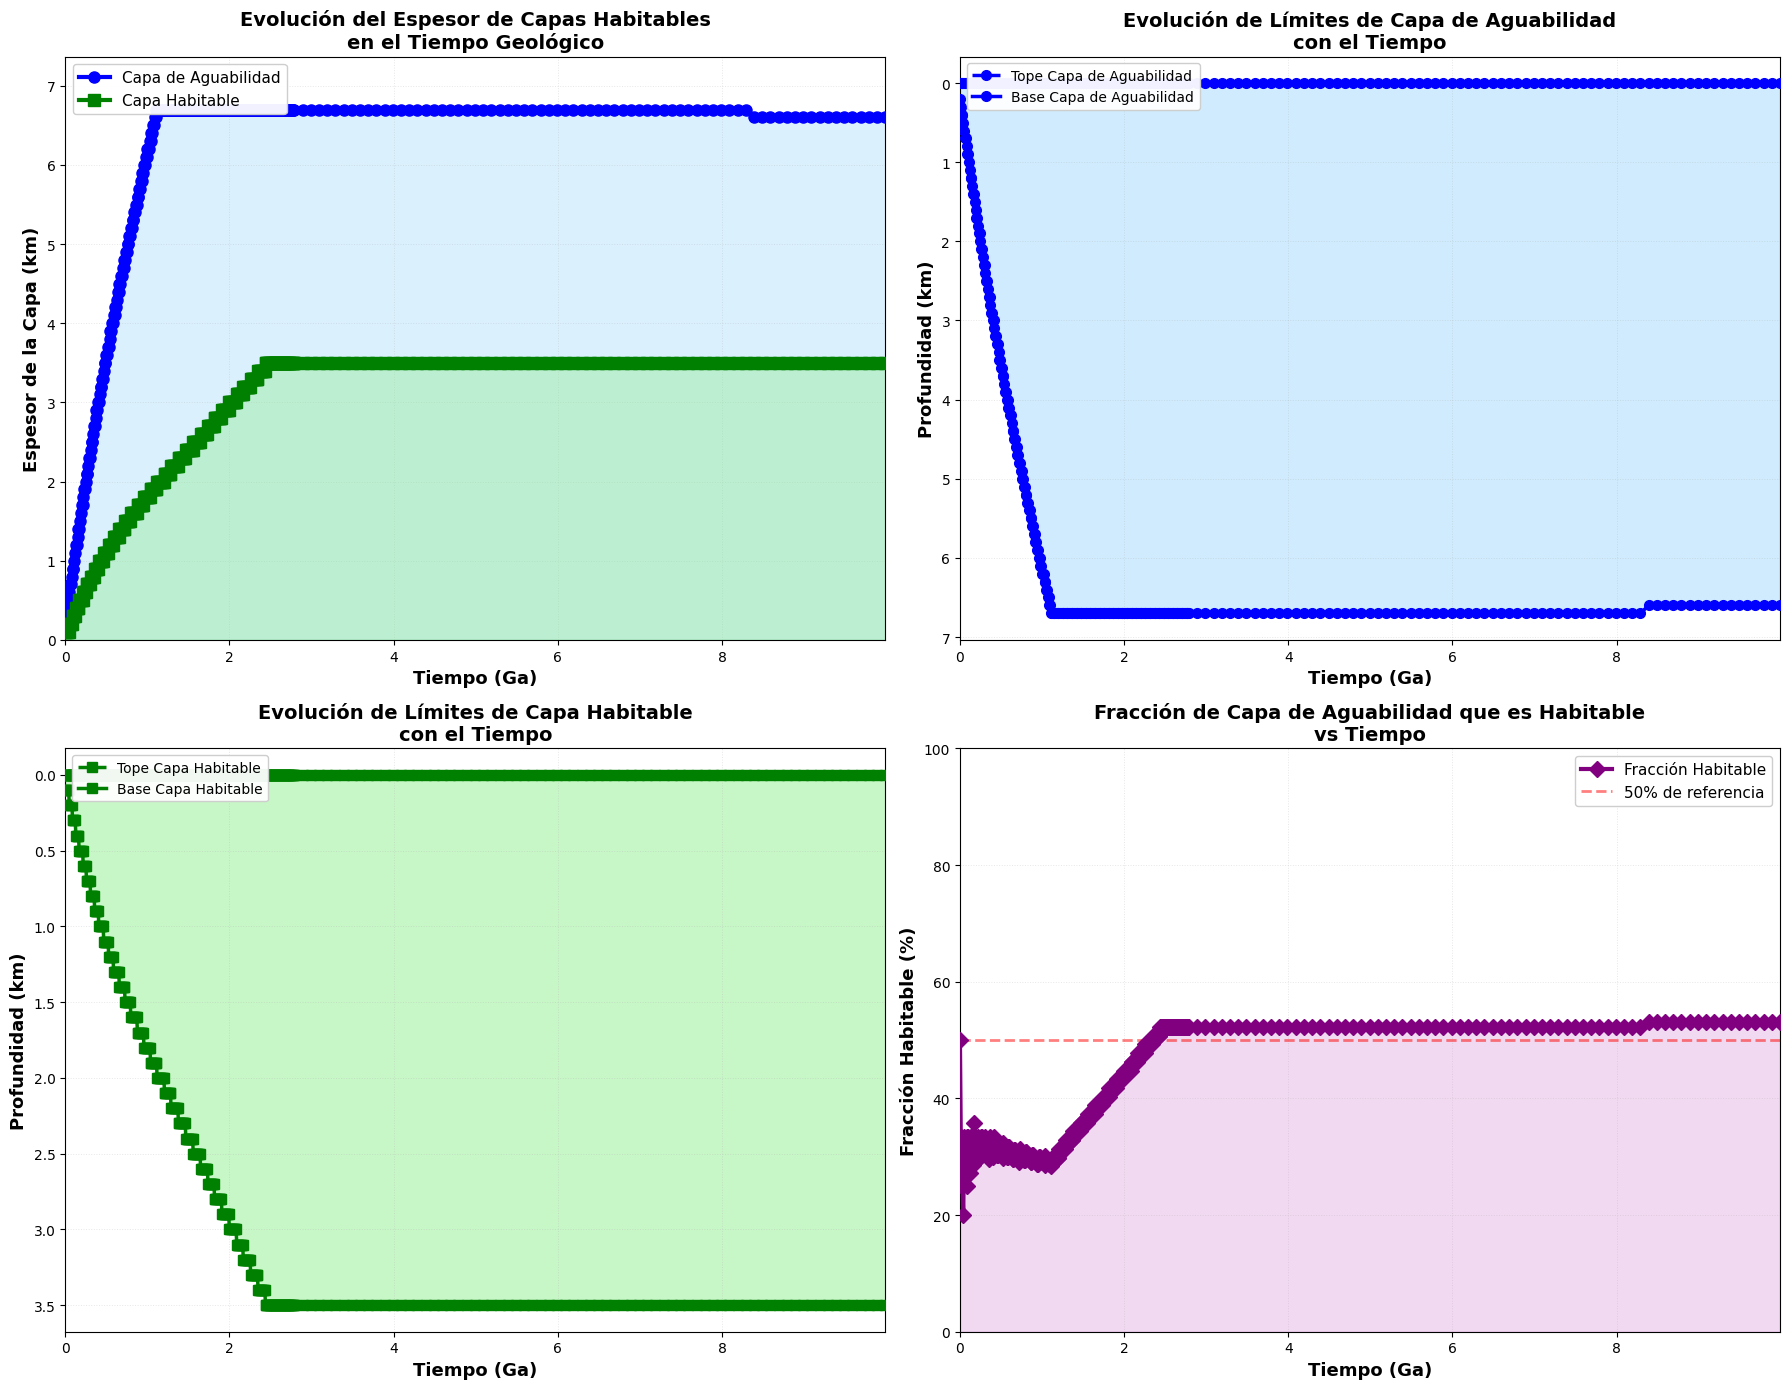


RESUMEN ESTADÍSTICO: EVOLUCIÓN TEMPORAL DE HABITABILIDAD

📊 Capa DE AGUABILIDAD:
   Espesor inicial (0 Ga): 0.20 km
   Espesor final (9.99 Ga): 6.60 km
   Cambio total: +6.40 km
   Máximo espesor: 6.70 km (a 1.11 Ga)

🦠 Capa HABITABLE:
   Espesor inicial (0 Ga): 0.10 km
   Espesor final (9.99 Ga): 3.50 km
   Cambio total: +3.40 km
   Máximo espesor: 3.50 km (a 2.44 Ga)

📉 FRACCIÓN HABITABLE:
   Inicial (0 Ga): 50.0%
   Final (9.99 Ga): 53.0%
   Cambio total: +3.0%



In [26]:
plots_habitability_vs_time_geological(data_time)